In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/customer.csv')

In [4]:
print(df)
df.columns

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.shape

(7043, 21)

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# EDA

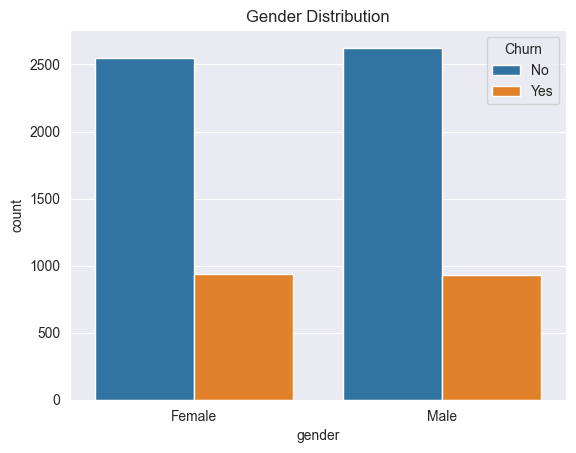

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='gender', data=df, hue='Churn')
plt.title('Gender Distribution')
plt.show()

SeniorCitizen  Churn
0              No       4508
               Yes      1393
1              No        666
               Yes       476
Name: count, dtype: int64


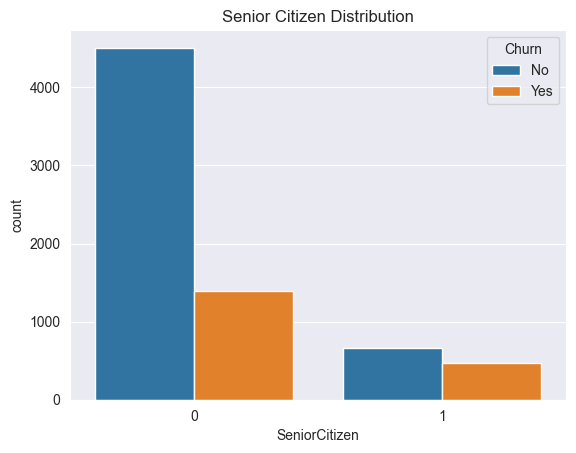

In [13]:
print(df.groupby('SeniorCitizen')['Churn'].value_counts())

sns.countplot(x='SeniorCitizen', data=df, hue='Churn')
plt.title('Senior Citizen Distribution')
plt.show()

<Axes: xlabel='tenure', ylabel='Count'>

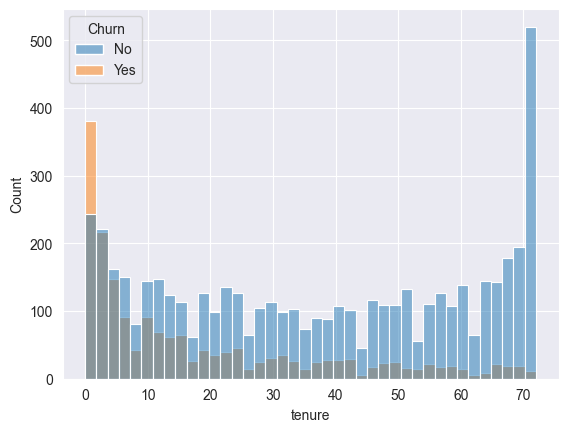

In [12]:
sns.histplot(x='tenure', data=df, hue='Churn', bins=40)

## Видно что чем дольше клиент с нами, тем меньше шанс его ухода

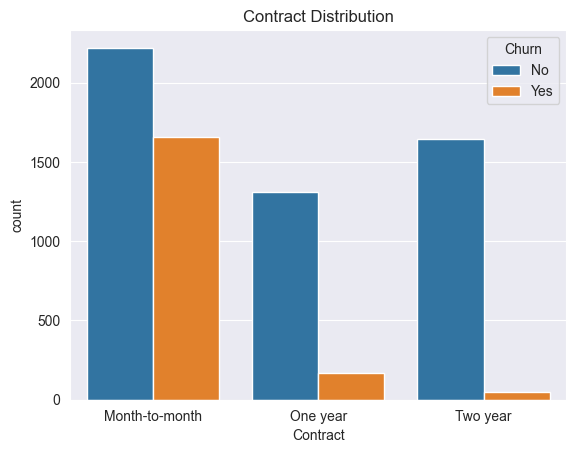

In [14]:
sns.countplot(x='Contract', data=df, hue='Churn')
plt.title('Contract Distribution')
plt.show()

## Есть тенденция, чем дольше длится контракт с клиентом тем ниже шанс ухода

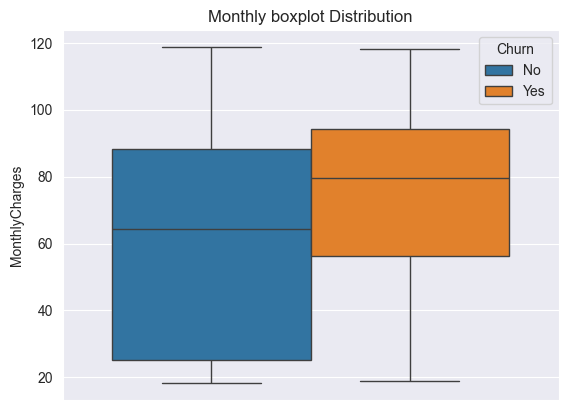

In [15]:
sns.boxplot(y='MonthlyCharges', data=df, hue='Churn')
plt.title('Monthly boxplot Distribution')
plt.show()

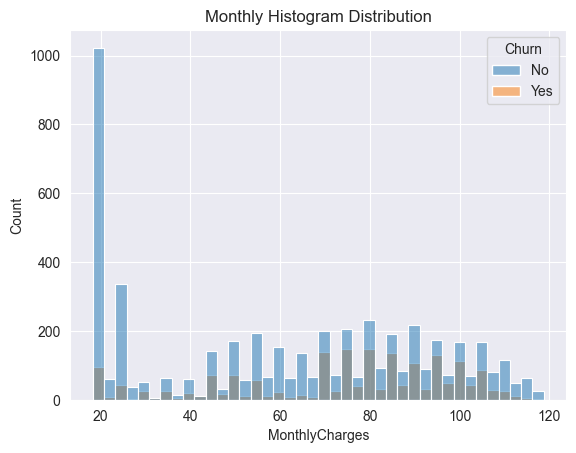

In [16]:
sns.histplot(x='MonthlyCharges', data=df, hue='Churn', bins=40)
plt.title('Monthly Histogram Distribution')
plt.show()

## Чем больше месячный платеж, тем выше риск ухода

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object
0


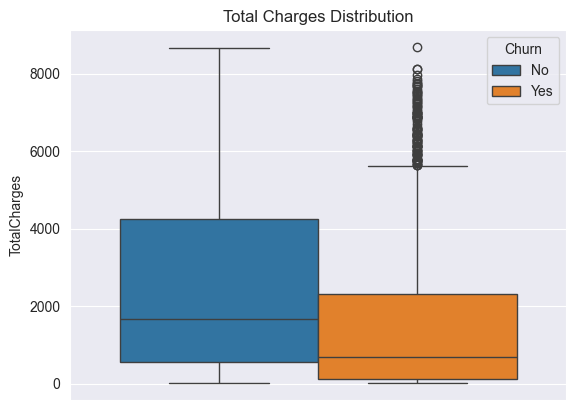

In [17]:
print(df['TotalCharges'].describe())
print(df['TotalCharges'].isna().sum())

t = df[df['TotalCharges'] != ' ']
t['TotalCharges'] = t['TotalCharges'].astype(float).round(2)

sns.boxplot(y='TotalCharges', data=t, hue='Churn')
plt.title('Total Charges Distribution')
plt.show()

## Присутствуют сильные выбросы у ушедших, скорее всего нерелевантный признак

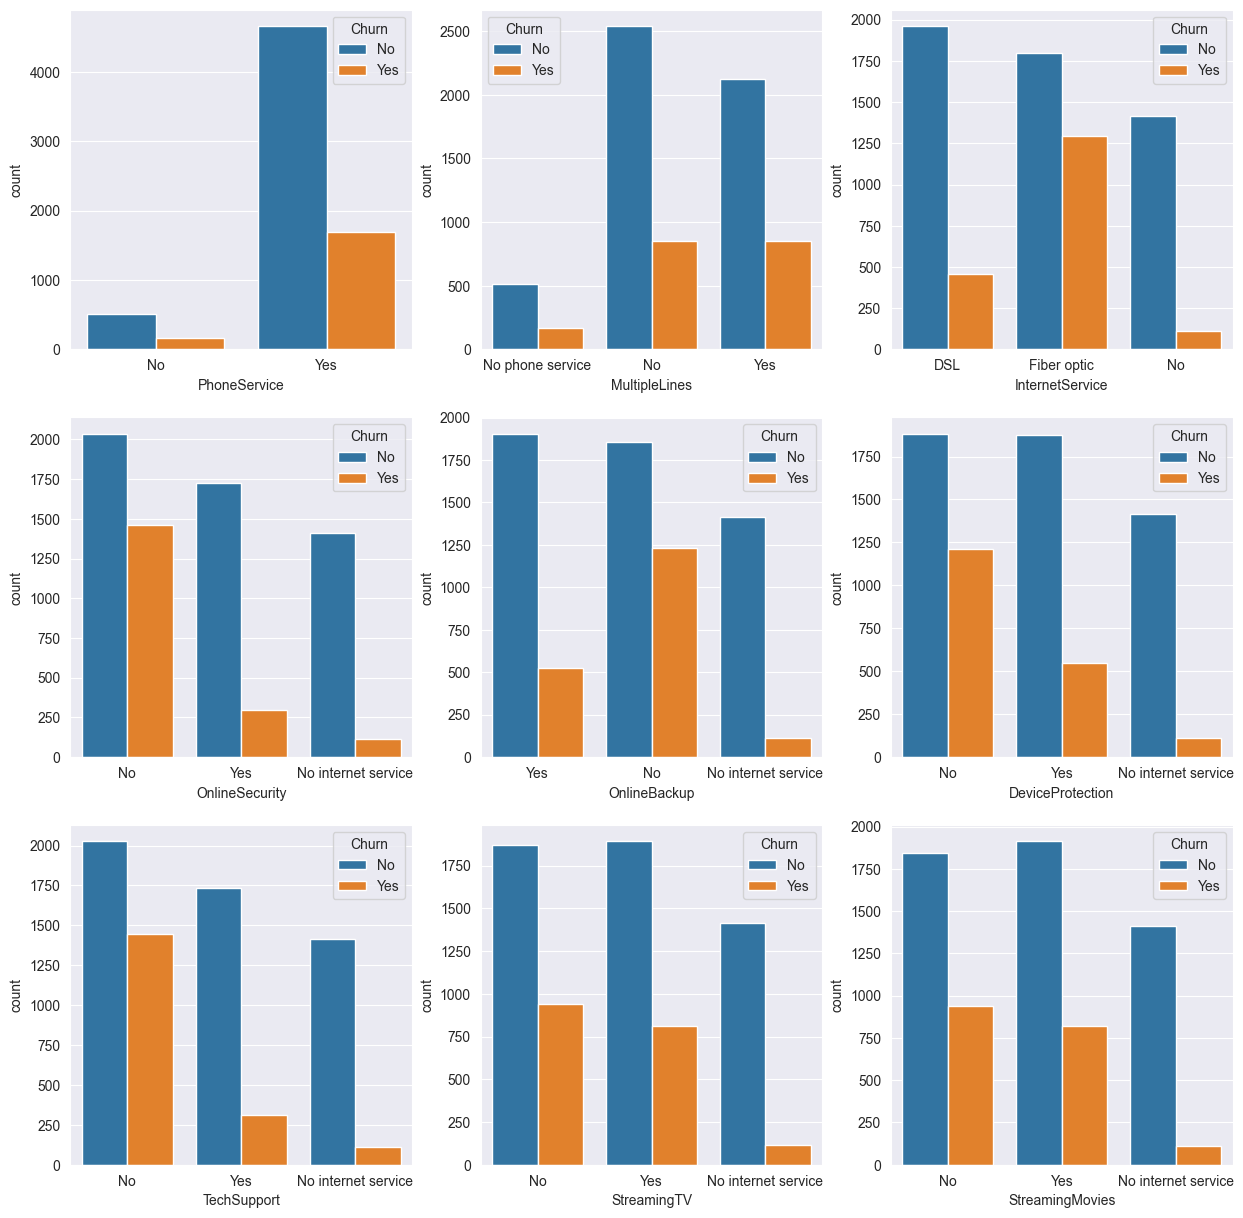

In [19]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

plt.figure(figsize=(15,15))
for i, col in enumerate(cols, start=1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df, hue='Churn')

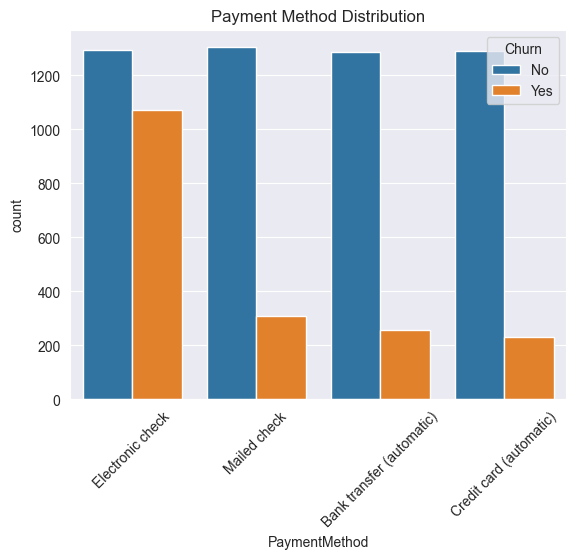

In [20]:
sns.countplot(x='PaymentMethod', data=df, hue='Churn')
plt.title('Payment Method Distribution')
plt.xticks(rotation=45)
plt.show()

## Заметно что люди с электронными чеками заметно чаще уходят

                MonthlyCharges  TotalCharges    tenure
MonthlyCharges        1.000000      0.651182  0.247900
TotalCharges          0.651182      1.000000  0.826164
tenure                0.247900      0.826164  1.000000


<Axes: >

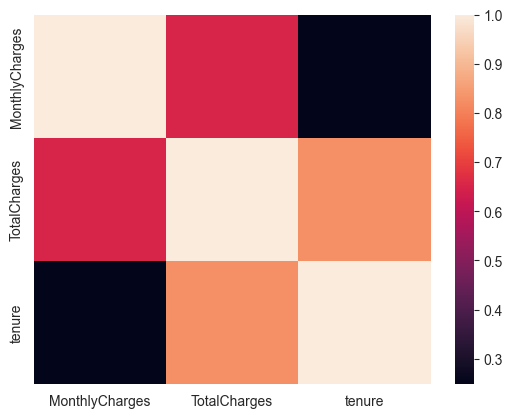

In [22]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

numerical_features = ['MonthlyCharges', 'TotalCharges', 'tenure']

print(df[numerical_features].corr())
sns.heatmap(df[numerical_features].corr())

## Заметны сильные корреляции между MonthlyCharges-TotalCharges и tenure-TotalCharges, возможна мульти корреляция надо убрать общие платежи, если буду использовать линейную модель